In [1]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

jit_find_library(): Unable to load "/usr/lib/llvm-15/lib/libLLVM.so": /home/jonathan/miniconda3/envs/volprim/lib/python3.11/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/llvm-15/lib/libLLVM.so)!


In [2]:
import volprim
from volprim.integrators.common import *

In [3]:
from scripts.radiosity.radiance_cache import RadianceCache
from scripts.radiosity.surface_sampler import SceneSurfaceSampler
from scripts.radiosity.vertex_bsdf import Diffuse, Principled

scene_path = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_const_shadow_2/matpreview.xml"
scene = mi.load_file(scene_path)
gs_path = "/home/jonathan/Documents/taming-3dgs/output/matpreview_const_shadow/point_cloud/iteration_7000/point_cloud.ply"

mesh_indices = [2]

if mesh_indices is None:
    mesh_indices = [i for i in range(len(scene.shapes()))]

radiance_cache = RadianceCache(scene, gs_path)
scene_sampler = SceneSurfaceSampler(scene, mesh_indexes=mesh_indices)
bsdf_train = Principled()
# bsdf_train = Diffuse()

In [4]:
for mesh_idx, mesh in enumerate(scene.shapes()):
    if not(mesh.shape_type() == mi.ShapeType.Mesh):
        continue

    if mesh_idx not in mesh_indices:
        continue
    bsdf_train.initialize_mesh_attributes(mesh, [0.5, 0.5, 0.5], 0.8, 0.1) # Principled
    # bsdf_train.initialize_mesh_attributes(mesh, [0.5, 0.5, 0.5]) # Diffuse

In [ ]:
from scripts.radiosity.radiance_cache import _compute_loss_mis_woRIS
from scripts.radiosity.bsdf_utils import render_base_color, render_attributes
from scripts.radiosity.regularizer import TVRegularizer
from scripts.largesteps_generic import LargeSteps
from time import time
import os

NUM_GEO_SAMPLES = 1 << 12
NUM_WI_DIRECTIONS = 32 << 0
NUM_WO = 8 << 0

mesh_names = [mesh.id() for mesh_idx, mesh in enumerate(scene.shapes()) if mesh_idx in mesh_indices]
mesh_name = mesh_names[0]

params = mi.traverse(scene)
opt = mi.ad.Adam(lr=0.05, mask_updates=True)
keys = bsdf_train.register_params(opt, params)
lambda_ = 0.6
ls = LargeSteps(params[f'{mesh_name}.vertex_positions'], params[f'{mesh_name}.faces'], lambda_)
reg = TVRegularizer(scene)
TV_coeff = 0.1

lr_dict = {}
for key in keys:
    opt_key = f'{key}_u'
    if "base_color" in key:
        opt[opt_key] = ls.to_differential_3(params[key])
    else:
        opt[opt_key] = ls.to_differential_1(params[key])

opt.set_learning_rate(lr_dict)

In [ ]:
from scripts.restir.reservoir import MultiReservoirVector3f


losses = []

max_iterations = 300

Nf = dr.gather(mi.MeshPtr, scene.shapes_dr(), mesh_indices).face_count()[0]
num_slots = 2
rsv = MultiReservoirVector3f(Nf, num_slots)



fp = f"output/matpreview_constant/shadow_2/woris/"
try:
    os.mkdir(fp)
except:
    pass

for it in range(max_iterations):
    if it % 10 == 0:
        render_base_color(scene, None, True, fp + f"itr={it}")

    if it % 50 == 0:
        render_attributes(scene, None, True, fp + f"itr={it}_attr")


    time1 = time()

    lambert_loss = 0.0
    
    for key in keys:
        # Retrieve the per-vertex data from the latent variable
        if "base_color" in key:
            params[key] = ls.from_differential_3(opt[f'{key}_u'])
        else:
            params[key] = ls.from_differential_1(opt[f'{key}_u'])
    
        # Post-process the optimized parameters to ensure legal color values.
        if "roughness" in key:
            params[key] = dr.clip(params[key], 0.1, 1.0)
        else:
            params[key] = dr.clip(params[key], 0.0, 1.0)
        params.update()

        # if "roughness" in key:
        #     lambert_loss += dr.mean(dr.abs(1.0 - params[key]))
        # elif "metallic" in key:
        #     lambert_loss += dr.mean(dr.abs(params[key]))

        if "metallic" in key:
            metal = params[key]
            lambert_loss += dr.mean(dr.abs(metal * (1.0 - metal)))

    # # Evaluate the objective function for the current BSDF params
    # loss = _compute_loss_mis_RT(scene_sampler, radiance_cache, bsdf_train, 
    #     NUM_GEO_SAMPLES, NUM_WI_DIRECTIONS, num_wo = NUM_WO, rng_state = it, spp = 64)
    loss = _compute_loss_mis_woRIS(scene_sampler, radiance_cache, bsdf_train, 
        NUM_GEO_SAMPLES, NUM_WI_DIRECTIONS, num_wo = NUM_WO, rng_state = it, spp = 64)

    # Add regularization
    TV_loss = TV_coeff * reg.compute_loss(scene, mesh_indices=[2], attrib_keys=["vertex_bsdf_roughness", "vertex_bsdf_metallic"])
    loss += TV_loss

    loss += 1e-3 * lambert_loss

    # Backpropagate through the rendering process
    dr.backward(loss)

    # Optimizer: take a gradient descent step
    opt.step()

    # Post-process the optimized parameters to ensure legal color values.
    for key in keys:
        opt[key] = dr.clip(opt[key], 0.0, 1.0)

    if it in (int(0.6 * max_iterations), int(0.8 * max_iterations)):
        opt.set_learning_rate(0.5 * opt.lr['vertex_bsdf_base_color'])
        NUM_WI_DIRECTIONS *= 2
        
    losses.append(loss.numpy())
    time2 = time()
    print(f"Iteration {1+it:03d} [{time2 - time1:2f}]: Loss = {loss}")

Iteration 001 [2.229619]: Loss = [0.0255847]
Iteration 002 [2.222000]: Loss = [0.0242527]
Iteration 003 [2.213529]: Loss = [0.0226396]
Iteration 004 [2.225768]: Loss = [0.0214432]
Iteration 005 [2.476209]: Loss = [0.0196202]
Iteration 006 [2.211247]: Loss = [0.0181291]
Iteration 007 [2.213246]: Loss = [0.0163659]
Iteration 008 [2.189301]: Loss = [0.0147611]
Iteration 009 [2.225072]: Loss = [0.0139122]
Iteration 010 [2.205858]: Loss = [0.0125264]
Iteration 011 [2.233345]: Loss = [0.0110724]
Iteration 012 [2.226299]: Loss = [0.00989886]
Iteration 013 [2.212585]: Loss = [0.00914652]
Iteration 014 [2.239104]: Loss = [0.00817498]
Iteration 015 [2.209894]: Loss = [0.00725606]
Iteration 016 [2.232240]: Loss = [0.00651435]
Iteration 017 [2.242353]: Loss = [0.0060579]
Iteration 018 [2.250518]: Loss = [0.00537302]
Iteration 019 [2.222966]: Loss = [0.00504034]
Iteration 020 [2.221579]: Loss = [0.00463473]
Iteration 021 [2.217966]: Loss = [0.00432059]
Iteration 022 [2.208552]: Loss = [0.00412025]


In [23]:
mi.util.write_bitmap(fp + "init_render.exr", mi.render(scene))

In [24]:
# sampler = mi.load_dict({'type':'independent'})
# si, num_points = scene_sampler.sample_stratified(sampler, 12)[:2]
# sampler.seed(0, num_points)
# ds, spec = scene.sample_emitter_direction(si, sampler.next_2d())
# ds.pdf * spec

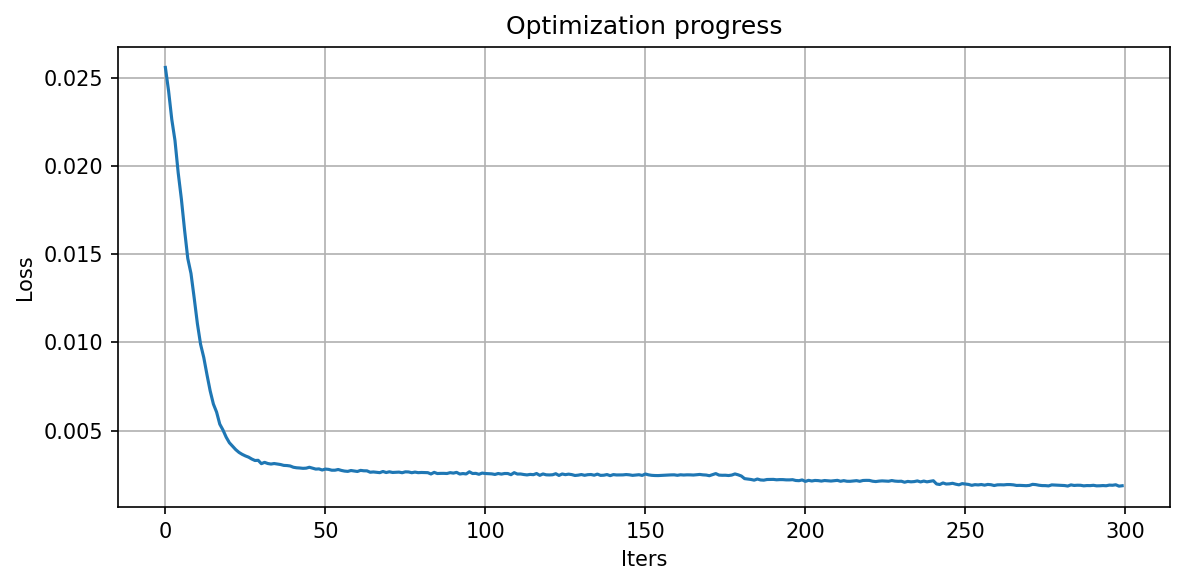

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4), dpi=150)
plt.title("Optimization progress")
plt.plot(np.array(losses))
plt.xlabel("Iters")
plt.ylabel("Loss")
plt.grid()
plt.tight_layout()
plt.savefig(fp + "loss.png")

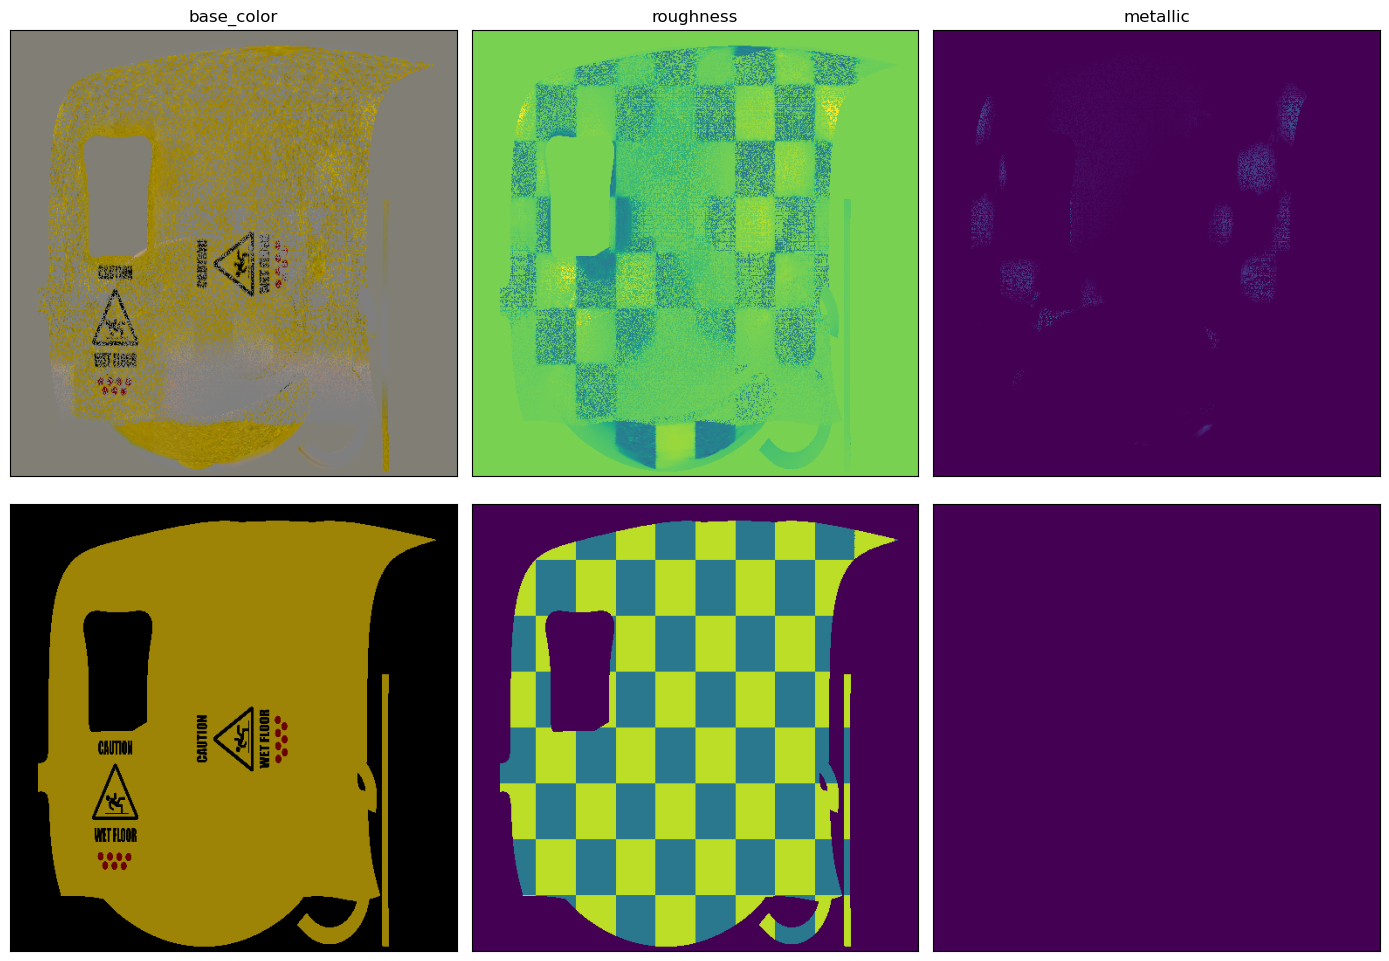

In [26]:
mesh = scene.shapes_dr()[mesh_indices[0]]
Nuv = 512
uu, vv = dr.meshgrid(dr.linspace(mi.Float,-0.2,1.2,Nuv), dr.linspace(mi.Float,0,1,Nuv))
si = mesh.eval_parameterization(mi.Point2f(dr.ravel(uu), dr.ravel(vv)))

base_color = mi.TensorXf(dr.ravel(mesh.eval_attribute_3("vertex_bsdf_base_color", si)), shape=(Nuv,Nuv,3))
roughness  = mi.TensorXf(dr.ravel(mesh.eval_attribute_1("vertex_bsdf_roughness",  si)), shape=(Nuv,Nuv))
metallic   = mi.TensorXf(dr.ravel(mesh.eval_attribute_1("vertex_bsdf_metallic",   si)), shape=(Nuv,Nuv))

base_color_ref = mi.TensorXf(dr.ravel(si.bsdf().eval_diffuse_reflectance(si)),    shape=(Nuv,Nuv,3))
roughness_ref  = mi.TensorXf(dr.ravel(si.bsdf().eval_attribute_1("roughness", si)), shape=(Nuv,Nuv))
metallic_ref   = mi.TensorXf(dr.ravel(si.bsdf().eval_attribute_1("metallic", si)),  shape=(Nuv,Nuv))

plt.figure(figsize=(14,10), dpi=100)
plt.subplot(231); plt.title("base_color"); plt.imshow(base_color); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.subplot(234); plt.imshow(base_color_ref); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.subplot(232); plt.title("roughness"); plt.imshow(roughness,     vmin=0.0, vmax=1.0); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.subplot(235); plt.imshow(roughness_ref, vmin=0.0, vmax=1.0); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.subplot(233); plt.title("metallic"); plt.imshow(metallic,      vmin=0.0, vmax=1.0); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.subplot(236); plt.imshow(metallic_ref,  vmin=0.0, vmax=1.0); ax=plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(fp + "final_texture.png")

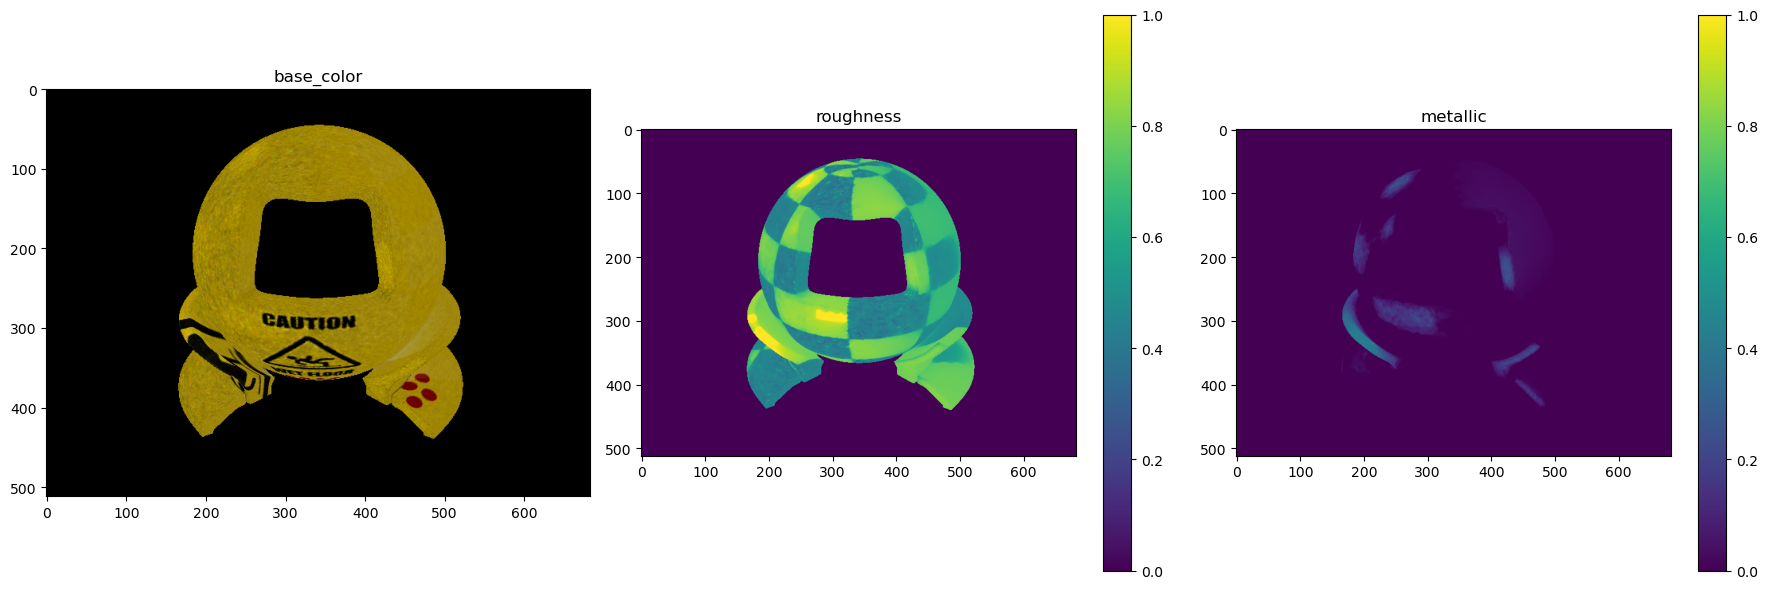

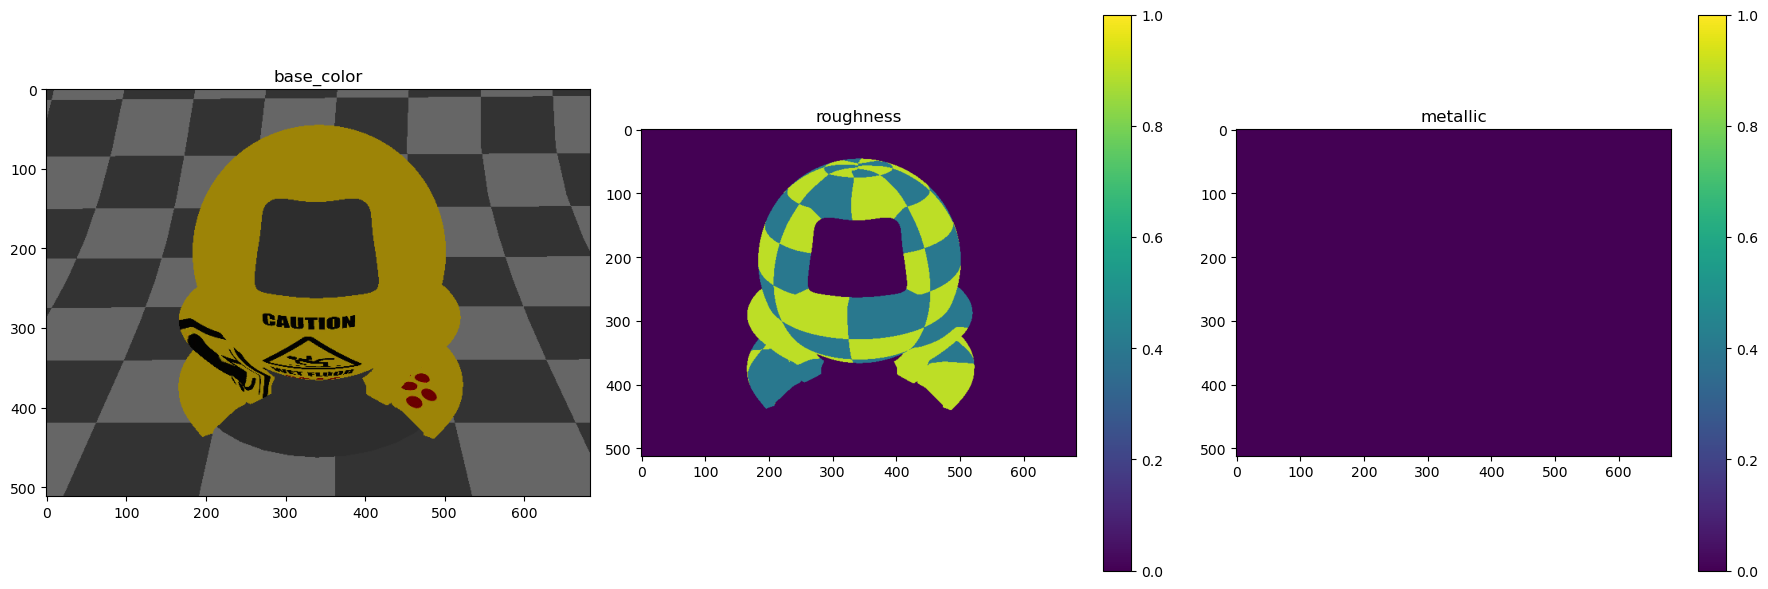

In [27]:
from scripts.radiosity.bsdf_utils import render_attributes, render_attributes_gt

out = render_attributes(scene, None, True, fp + "final")
# BSDF final values
plt.figure(figsize=(18,6), dpi=100)
plt.subplot(131); plt.imshow(out[:,:,:3]); plt.title("base_color")
plt.subplot(132); plt.imshow(out[:,:,3], vmin=0.0, vmax=1.0); plt.title("roughness"); plt.colorbar()
plt.subplot(133); plt.imshow(out[:,:,4], vmin=0.0, vmax=1.0); plt.title("metallic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out[:,:,5], vmin=0.0, vmax=1.0); plt.title("anisotropic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out[:,:,6], vmin=0.0, vmax=1.0); plt.title("spec_tint");  plt.colorbar()
plt.tight_layout()
plt.gcf().savefig(fp + "final.png")

out_gt = render_attributes_gt(scene, None, True, fp + "reference")

# BSDF final values
plt.figure(figsize=(18,6), dpi=100)
plt.subplot(131); plt.imshow(out_gt[:,:,:3]); plt.title("base_color")
plt.subplot(132); plt.imshow(out_gt[:,:,3], vmin=0.0, vmax=1.0); plt.title("roughness"); plt.colorbar()
plt.subplot(133); plt.imshow(out_gt[:,:,4], vmin=0.0, vmax=1.0); plt.title("metallic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out_gt[:,:,5], vmin=0.0, vmax=1.0); plt.title("anisotropic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out_gt[:,:,6], vmin=0.0, vmax=1.0); plt.title("spec_tint");  plt.colorbar()
plt.tight_layout()
plt.gcf().savefig(fp + "ref.png")


In [28]:
# from scripts.radiosity.bsdf_utils import ps_visualize_textures

# ps_visualize_textures(scene)

In [29]:
# from scripts.io_utils import export_trained_scene

# envmap_new = None
# envmap_new = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/envmaps/gym.exr"

# trained_fp = export_trained_scene(scene, scene_path, [2], envmap_fp=envmap_new)[1]

In [30]:
# plt.figure(figsize=(12,4))
# plt.subplot(121)
# plt.imshow(mi.render(mi.load_file(f"{trained_fp}".replace("trained", "ref"))))
# plt.title("Relight, reference")
# plt.subplot(122)
# plt.title("Relight, recon")
# plt.imshow(mi.render(mi.load_file(f"{trained_fp}")))